# Course Project
Predicting Graduation Rates of U.S. Universities Using Machine Learning

Dataset: `usnews_data.txt`

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score

## Preprocessing

### Dataset

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/TheChroniclerr/CP322/refs/heads/main/course_project/assets/dataset/usnews_data.txt')
df.head()

,1061,Alaska Pacific University,AK,2,490,482,972,20,440,530,...,2500,130,800,1500,76,72,11.9,2.1,10922,15
0,1063,University of Alaska at Fairbanks,AK,1,499,462,961,22,*,*,...,1790,155,650,2304,67,*,10.0,8,11935,*
1,1065,University of Alaska Southeast,AK,1,*,*,*,*,*,*,...,2250,34,500,1162,39,51,9.5,*,9584,39
2,11462,University of Alaska at Anchorage,AK,1,459,422,881,20,*,*,...,2520,114,580,1260,48,*,13.7,6,8046,*
3,1002,Alabama Agri. & Mech. Univ.,AL,1,*,*,*,17,*,*,...,1442,155,500,850,53,53,14.3,*,7043,40
4,1003,Faulkner University,AL,2,*,*,*,20,*,*,...,1700,300,350,*,52,56,32.8,*,3971,55


In [4]:
# Set feature names
columns = [
    "fice",
    "college_name",
    "state",
    "public_private",
    "avg_math_sat",
    "avg_verbal_sat",
    "avg_combined_sat",
    "avg_act",
    "math_sat_q1",
    "math_sat_q3",
    "verbal_sat_q1",
    "verbal_sat_q3",
    "act_q1",
    "act_q3",
    "applications",
    "accepted",
    "enrolled",
    "pct_top10",
    "pct_top25",
    "fulltime_undergrad",
    "parttime_undergrad",
    "tuition_in_state",
    "tuition_out_state",
    "room_board_cost",
    "room_cost",
    "board_cost",
    "additional_fees",
    "book_cost",
    "personal_spending",
    "pct_faculty_phd",
    "pct_faculty_terminal",
    "student_faculty_ratio",
    "pct_alumni_donate",
    "instructional_expenditure",
    "graduation_rate"
]

df.columns = columns
df

,fice,college_name,state,public_private,avg_math_sat,avg_verbal_sat,avg_combined_sat,avg_act,math_sat_q1,math_sat_q3,...,board_cost,additional_fees,book_cost,personal_spending,pct_faculty_phd,pct_faculty_terminal,student_faculty_ratio,pct_alumni_donate,instructional_expenditure,graduation_rate
0,1063,University of Alaska at Fairbanks,AK,1,499,462,961,22,*,*,...,1790,155,650,2304,67,*,10.0,8,11935,*
1,1065,University of Alaska Southeast,AK,1,*,*,*,*,*,*,...,2250,34,500,1162,39,51,9.5,*,9584,39
2,11462,University of Alaska at Anchorage,AK,1,459,422,881,20,*,*,...,2520,114,580,1260,48,*,13.7,6,8046,*
3,1002,Alabama Agri. & Mech. Univ.,AL,1,*,*,*,17,*,*,...,1442,155,500,850,53,53,14.3,*,7043,40
4,1003,Faulkner University,AL,2,*,*,*,20,*,*,...,1700,300,350,*,52,56,32.8,*,3971,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296,3826,West Virginia State College,WV,1,*,*,*,18,*,*,...,1700,50,750,750,38,38,19.2,4,3839,*
1297,3827,West Virginia University,WV,1,507,439,946,22,450,560,...,2026,*,*,*,83,86,13.4,*,8318,57
1298,3830,West Virginia Wesleyan College,WV,2,489,439,928,23,420,560,...,2025,*,450,1100,58,81,16.4,42,8080,67
1299,3831,Wheeling Jesuit College,WV,2,479,433,912,22,410,520,...,2445,*,600,600,66,71,14.1,27,7494,72


### Cleaning

In [5]:
# Replace '*' with nan
df.replace("*", np.nan, inplace=True)

# Convert data to numeric
df = df.apply(pd.to_numeric, errors="coerce")

df.isna().sum().sort_values(ascending=False)

,0
college_name,1301
state,1301
act_q3,639
act_q1,639
avg_act,588
math_sat_q1,530
verbal_sat_q1,530
math_sat_q3,530
verbal_sat_q3,530
avg_math_sat,525


In [6]:
# Drop identifiers,redundant features, and feature with too many missing values (>500)
df = df.drop(columns=[
    # Identifiers
    "fice",
    "college_name",
    "state",
    # Missing
    "act_q3",
    "act_q1",
    "avg_act",
    "math_sat_q1",
    "math_sat_q3",
    "verbal_sat_q1",
    "verbal_sat_q3",
    "avg_math_sat",
    "avg_verbal_sat",
    "avg_combined_sat",
    # Redundant
    "room_cost",
    "board_cost"
])

# Median imputate (<500)
df.fillna(df.median(), inplace=True)

df

,public_private,applications,accepted,enrolled,pct_top10,pct_top25,fulltime_undergrad,parttime_undergrad,tuition_in_state,tuition_out_state,room_board_cost,additional_fees,book_cost,personal_spending,pct_faculty_phd,pct_faculty_terminal,student_faculty_ratio,pct_alumni_donate,instructional_expenditure,graduation_rate
0,1,1852.0,1427.0,928.0,21.0,50.0,3885.0,4519.0,1742.0,5226.0,3590.0,155.0,650.0,2304.0,67.0,77.0,10.0,8.0,11935.0,60.0
1,1,146.0,117.0,89.0,4.0,24.0,492.0,1849.0,1742.0,5226.0,4764.0,34.0,500.0,1162.0,39.0,51.0,9.5,19.0,9584.0,39.0
2,1,2065.0,1598.0,1162.0,21.0,50.0,6209.0,10537.0,1742.0,5226.0,5120.0,114.0,580.0,1260.0,48.0,77.0,13.7,6.0,8046.0,60.0
3,1,2817.0,1920.0,984.0,21.0,50.0,3958.0,305.0,1700.0,3400.0,2550.0,155.0,500.0,850.0,53.0,53.0,14.3,19.0,7043.0,40.0
4,2,345.0,320.0,179.0,21.0,27.0,1367.0,578.0,5600.0,5600.0,3250.0,300.0,350.0,1248.0,52.0,56.0,32.8,19.0,3971.0,55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296,1,1869.0,1095.5,957.0,21.0,50.0,2817.0,1939.0,1988.0,4616.0,3200.0,50.0,750.0,750.0,38.0,38.0,19.2,4.0,3839.0,60.0
1297,1,9630.0,7801.0,2881.0,23.0,49.0,14524.0,1053.0,2128.0,6370.0,4310.0,265.0,500.0,1248.0,83.0,86.0,13.4,19.0,8318.0,57.0
1298,2,1566.0,1400.0,483.0,28.0,55.0,1509.0,170.0,14200.0,14200.0,3775.0,265.0,450.0,1100.0,58.0,81.0,16.4,42.0,8080.0,67.0
1299,2,903.0,755.0,213.0,15.0,49.0,971.0,305.0,10500.0,10500.0,4545.0,265.0,600.0,600.0,66.0,71.0,14.1,27.0,7494.0,72.0


### Feature Engineering

In [7]:
# Acceptance rate
df["acceptance_rate"] = df["accepted"] / df["applications"]

# Yield rate
df["yield_rate"] = df["enrolled"] / df["accepted"]

# Drop original data to avoid multicollinearity
df = df.drop(columns=["accepted", "applications", "enrolled"])

df

,public_private,pct_top10,pct_top25,fulltime_undergrad,parttime_undergrad,tuition_in_state,tuition_out_state,room_board_cost,additional_fees,book_cost,personal_spending,pct_faculty_phd,pct_faculty_terminal,student_faculty_ratio,pct_alumni_donate,instructional_expenditure,graduation_rate,acceptance_rate,yield_rate
0,1,21.0,50.0,3885.0,4519.0,1742.0,5226.0,3590.0,155.0,650.0,2304.0,67.0,77.0,10.0,8.0,11935.0,60.0,0.770518,0.650315
1,1,4.0,24.0,492.0,1849.0,1742.0,5226.0,4764.0,34.0,500.0,1162.0,39.0,51.0,9.5,19.0,9584.0,39.0,0.801370,0.760684
2,1,21.0,50.0,6209.0,10537.0,1742.0,5226.0,5120.0,114.0,580.0,1260.0,48.0,77.0,13.7,6.0,8046.0,60.0,0.773850,0.727159
3,1,21.0,50.0,3958.0,305.0,1700.0,3400.0,2550.0,155.0,500.0,850.0,53.0,53.0,14.3,19.0,7043.0,40.0,0.681576,0.512500
4,2,21.0,27.0,1367.0,578.0,5600.0,5600.0,3250.0,300.0,350.0,1248.0,52.0,56.0,32.8,19.0,3971.0,55.0,0.927536,0.559375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296,1,21.0,50.0,2817.0,1939.0,1988.0,4616.0,3200.0,50.0,750.0,750.0,38.0,38.0,19.2,4.0,3839.0,60.0,0.586142,0.873574
1297,1,23.0,49.0,14524.0,1053.0,2128.0,6370.0,4310.0,265.0,500.0,1248.0,83.0,86.0,13.4,19.0,8318.0,57.0,0.810073,0.369312
1298,2,28.0,55.0,1509.0,170.0,14200.0,14200.0,3775.0,265.0,450.0,1100.0,58.0,81.0,16.4,42.0,8080.0,67.0,0.893997,0.345000
1299,2,15.0,49.0,971.0,305.0,10500.0,10500.0,4545.0,265.0,600.0,600.0,66.0,71.0,14.1,27.0,7494.0,72.0,0.836102,0.282119


### Feature Selection

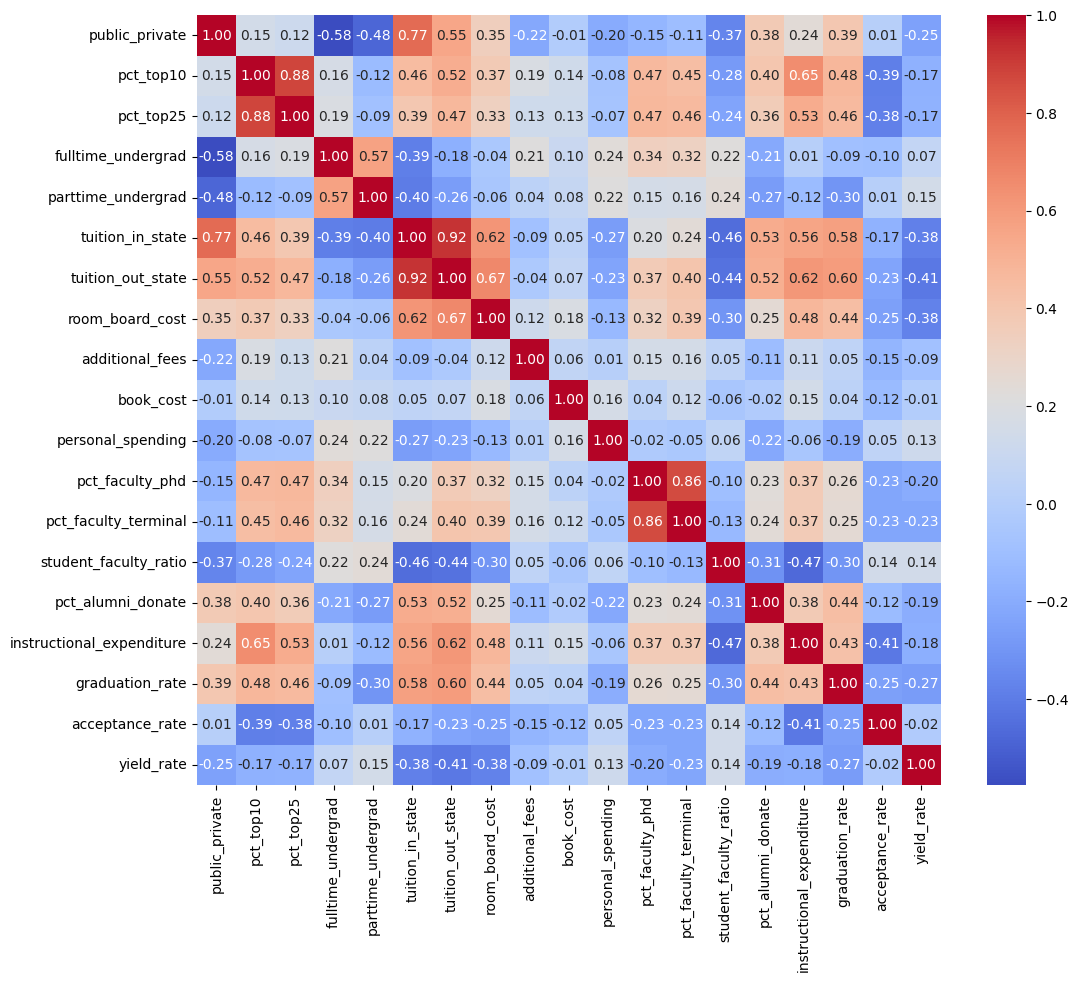

In [8]:
# Correlational analysis to reduce multicollinearity
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [9]:
# Drop highly correlated feature (>0.70)
df = df.drop(columns=[
    "pct_faculty_terminal",     # 0.86 with pct_faculty_phd
    "tuition_in_state",         # 0.92 with tuition_in_state, 0.77 with public_private
    "pct_top25"                 # 0.88 with pct_top10
])

### Export Processed

## Train/Test Split

In [10]:
# 80/20 split
X = df.drop("graduation_rate", axis=1)
y = df["graduation_rate"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Feature Scaling

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Train Models

In [12]:
lr = LinearRegression()
knn = KNeighborsRegressor(n_neighbors=12)
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)

# Fit models
lr.fit(X_train_scaled, y_train)
knn.fit(X_train_scaled, y_train)
rf.fit(X_train, y_train)

# Predict using models
lr_pred = lr.predict(X_test_scaled)
knn_pred = knn.predict(X_test_scaled)
rf_pred = rf.predict(X_test)

## Evaluate Models

In [13]:
# Linear Regression
print("Linear Regression")
print("R2:", r2_score(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

# KNN
print("\nKNN Regression")
print("R2:", r2_score(y_test, knn_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, knn_pred)))

# Random Forest
print("\nRandom Forest")
print("R2:", r2_score(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

Linear Regression
R2: 0.5228252837724108
RMSE: 11.759034018717744

KNN Regression
R2: 0.55521562690413
RMSE: 11.352923072135301

Random Forest
R2: 0.5611564483454609
RMSE: 11.276849786479573


### KNN Hyperparameter Tuning

In [28]:
rmse_values = []

for k in range(1, 40):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    pred = knn.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    rmse_values.append(rmse)

    print(f"n_neighbors={k}, RMSE={rmse}")

print("\nBest parameters:", rmse_values.index(min(rmse_values)) + 1)
print("Best RMSE:", min(rmse_values))

n_neighbors=1, RMSE=16.367662726906442
n_neighbors=2, RMSE=14.065902632189573
n_neighbors=3, RMSE=13.068343781650462
n_neighbors=4, RMSE=12.857912348499108
n_neighbors=5, RMSE=12.672859949922309
n_neighbors=6, RMSE=12.4199822859363
n_neighbors=7, RMSE=12.216544505416687
n_neighbors=8, RMSE=11.851165837375698
n_neighbors=9, RMSE=11.805086134958977
n_neighbors=10, RMSE=11.597876011121548
n_neighbors=11, RMSE=11.397851659422814
n_neighbors=12, RMSE=11.352923072135301
n_neighbors=13, RMSE=11.392379124450457
n_neighbors=14, RMSE=11.414838492327737
n_neighbors=15, RMSE=11.395983399120734
n_neighbors=16, RMSE=11.394663097366697
n_neighbors=17, RMSE=11.391217104514968
n_neighbors=18, RMSE=11.41379649743414
n_neighbors=19, RMSE=11.373658637541576
n_neighbors=20, RMSE=11.430693204107824
n_neighbors=21, RMSE=11.450584301034278
n_neighbors=22, RMSE=11.446093037307028
n_neighbors=23, RMSE=11.42621365553386
n_neighbors=24, RMSE=11.487280282589175
n_neighbors=25, RMSE=11.51120460323873
n_neighbors=26

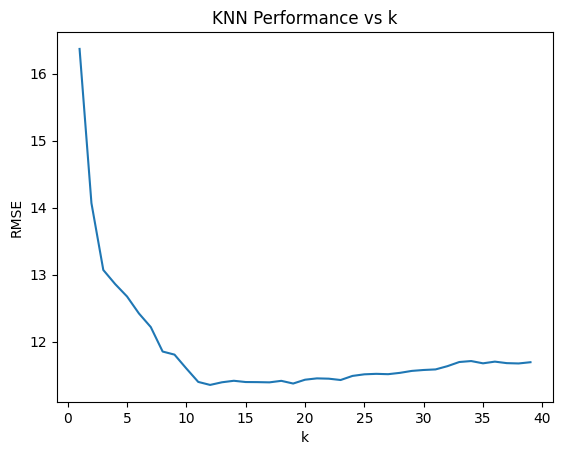

In [27]:
plt.plot(range(1,40), rmse_values)
plt.xlabel("k")
plt.ylabel("RMSE")
plt.title("KNN Performance vs k")
plt.show()

### Random Forest Hyperparameter Tuning

n_estimators=50, max_depth=5, RMSE=11.673339521231469
n_estimators=50, max_depth=10, RMSE=11.380938303704072
n_estimators=50, max_depth=15, RMSE=11.406132538737568
n_estimators=50, max_depth=None, RMSE=11.450760151447458
n_estimators=100, max_depth=5, RMSE=11.639406500620511
n_estimators=100, max_depth=10, RMSE=11.33159979002164
n_estimators=100, max_depth=15, RMSE=11.276849786479573
n_estimators=100, max_depth=None, RMSE=11.287812537307422
n_estimators=200, max_depth=5, RMSE=11.615021117222181
n_estimators=200, max_depth=10, RMSE=11.35999927129418
n_estimators=200, max_depth=15, RMSE=11.304322383318008
n_estimators=200, max_depth=None, RMSE=11.324100490357228

Best parameters: (100, 15)
Best RMSE: 11.276849786479573


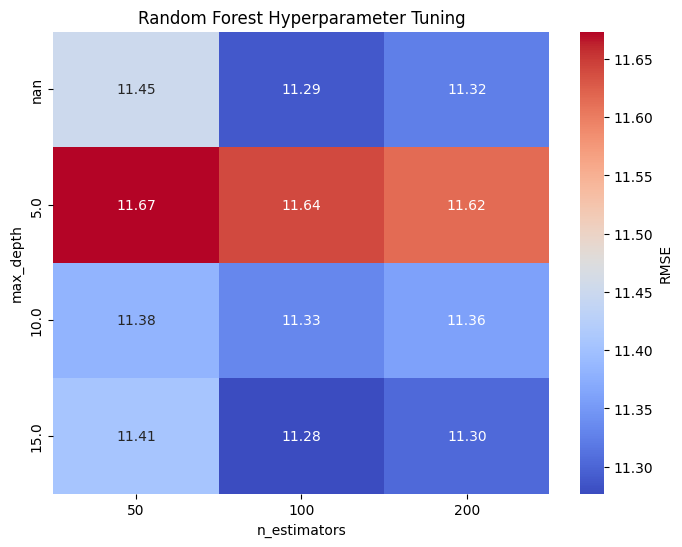

In [ ]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 15, None],
}

rmse_results = []

for n in param_grid["n_estimators"]:
    for depth in param_grid["max_depth"]:
        rf = RandomForestRegressor(
            n_estimators=n,
            max_depth=depth,
            random_state=42
        )
        rf.fit(X_train, y_train)
        pred = rf.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, pred))

        print(f"n_estimators={n}, max_depth={depth}, RMSE={rmse}")
        rmse_results.append({"n_estimators": n, "max_depth": depth, "RMSE": rmse})

best_result = min(rmse_results, key=lambda x: x["RMSE"])
print("\nBest parameters:", (best_result["n_estimators"], best_result["max_depth"]))
print("Best RMSE:", best_result["RMSE"])

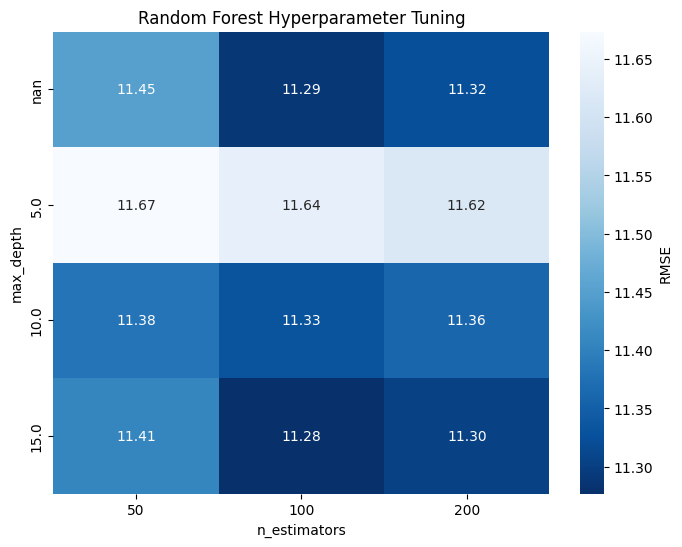

In [37]:
rmse_df = pd.DataFrame(rmse_results)
heatmap_data = rmse_df.pivot(index="max_depth", columns="n_estimators", values="RMSE")

plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="Blues_r", cbar_kws={'label': 'RMSE'})
plt.title("Random Forest Hyperparameter Tuning")
plt.ylabel("max_depth")
plt.xlabel("n_estimators")
plt.show()

## Model Comparison

               Model        R2       RMSE
0  Linear Regression  0.522825  11.759034
1                KNN  0.555216  11.352923
2      Random Forest  0.561156  11.276850


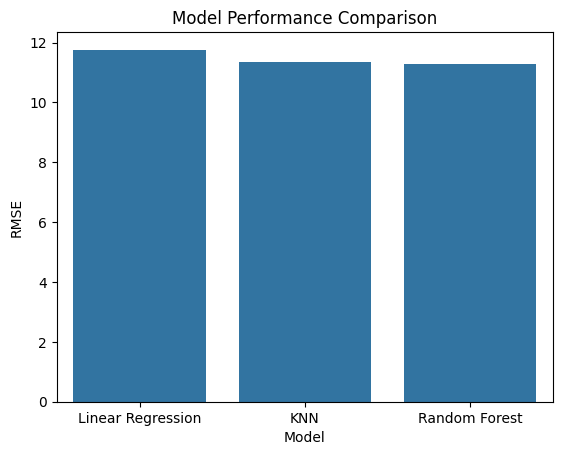

In [16]:
# Model comparison table
results = pd.DataFrame({
    "Model": ["Linear Regression", "KNN", "Random Forest"],
    "R2": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, knn_pred),
        r2_score(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, knn_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ]
})

print(results)

sns.barplot(data=results, x="Model", y="RMSE")
plt.title("Model Performance Comparison")
plt.show()

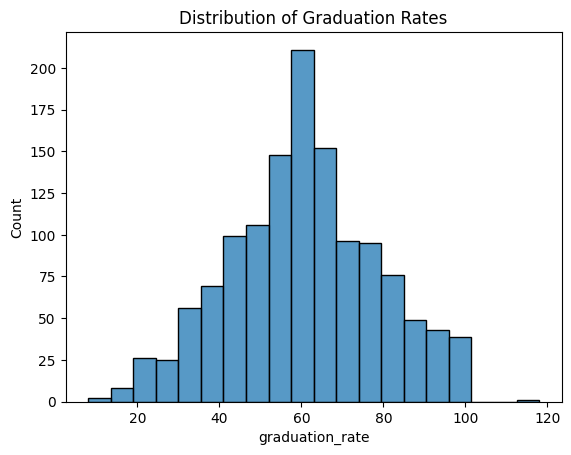

In [17]:
sns.histplot(df["graduation_rate"], bins=20)
plt.title("Distribution of Graduation Rates")
plt.show()

## Visualization

### Linear Regression

                      Feature  Coefficient
4           tuition_out_state     4.845117
1                   pct_top10     3.767426
3          parttime_undergrad    -3.166867
2          fulltime_undergrad     2.197510
5             room_board_cost     2.182003
11          pct_alumni_donate     2.165535
0              public_private     2.120119
12  instructional_expenditure    -1.286841
13            acceptance_rate    -0.943208
7                   book_cost    -0.614666
10      student_faculty_ratio    -0.427335
8           personal_spending    -0.345613
14                 yield_rate    -0.335914
6             additional_fees     0.147561
9             pct_faculty_phd     0.044392


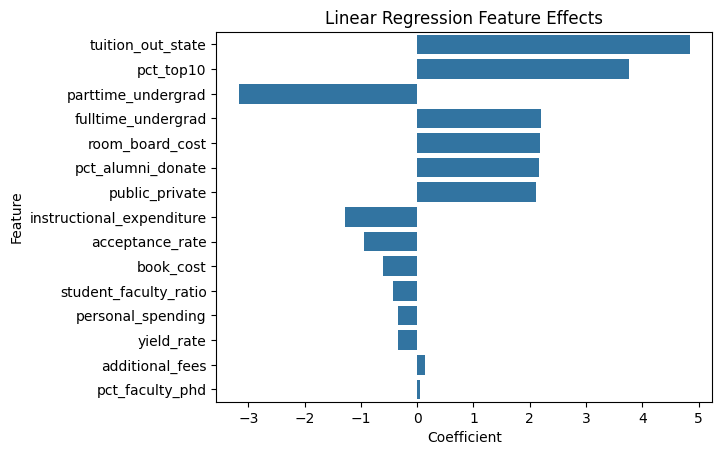

In [18]:
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

print(coeff_df)

sns.barplot(data=coeff_df, x="Coefficient", y="Feature")
plt.title("Linear Regression Feature Effects")
plt.show()

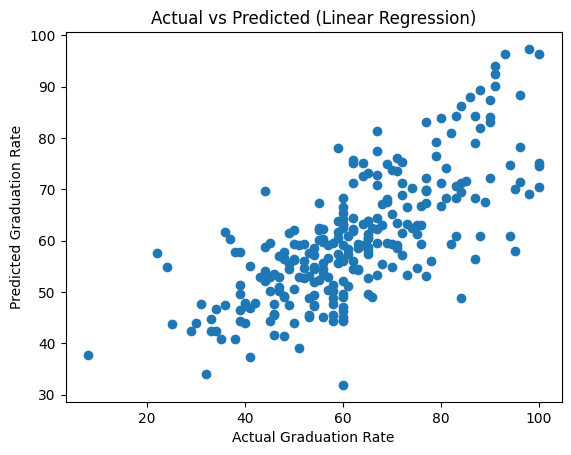

In [19]:
# Model quality
plt.scatter(y_test, lr_pred)

plt.xlabel("Actual Graduation Rate")
plt.ylabel("Predicted Graduation Rate")

plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

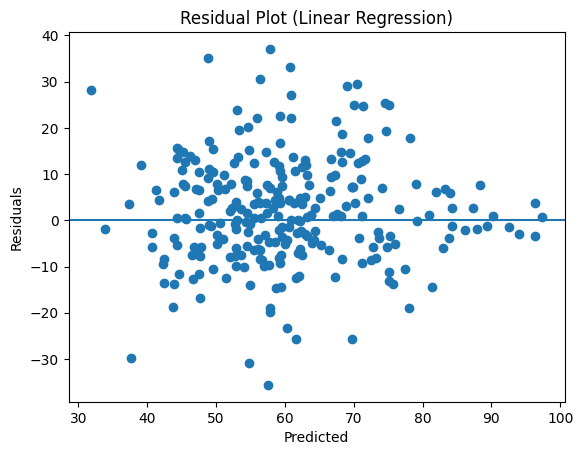

In [20]:
# Residual plot
residuals = y_test - lr_pred

plt.scatter(lr_pred, residuals)

plt.axhline(0)

plt.xlabel("Predicted")
plt.ylabel("Residuals")

plt.title("Residual Plot (Linear Regression)")
plt.show()

### KNN

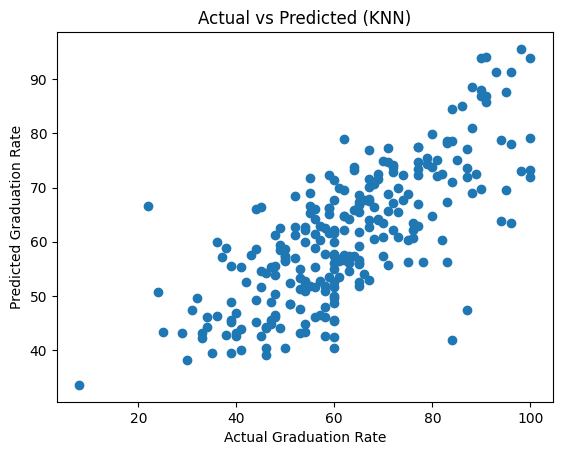

In [21]:
# Model quality
plt.scatter(y_test, knn_pred)

plt.xlabel("Actual Graduation Rate")
plt.ylabel("Predicted Graduation Rate")

plt.title("Actual vs Predicted (KNN)")
plt.show()

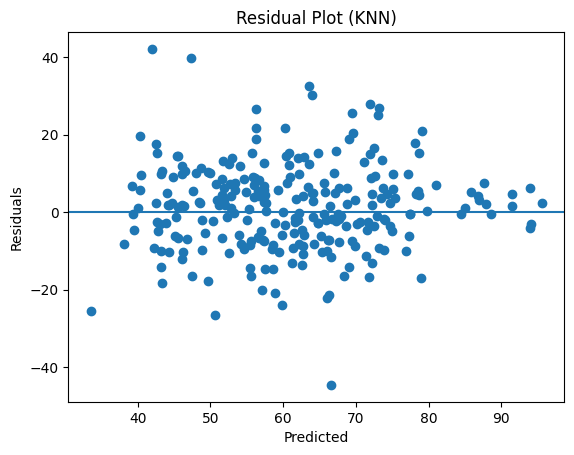

In [22]:
# Residual plot
residuals = y_test - knn_pred

plt.scatter(knn_pred, residuals)

plt.axhline(0)

plt.xlabel("Predicted")
plt.ylabel("Residuals")

plt.title("Residual Plot (KNN)")
plt.show()

### Random Forest

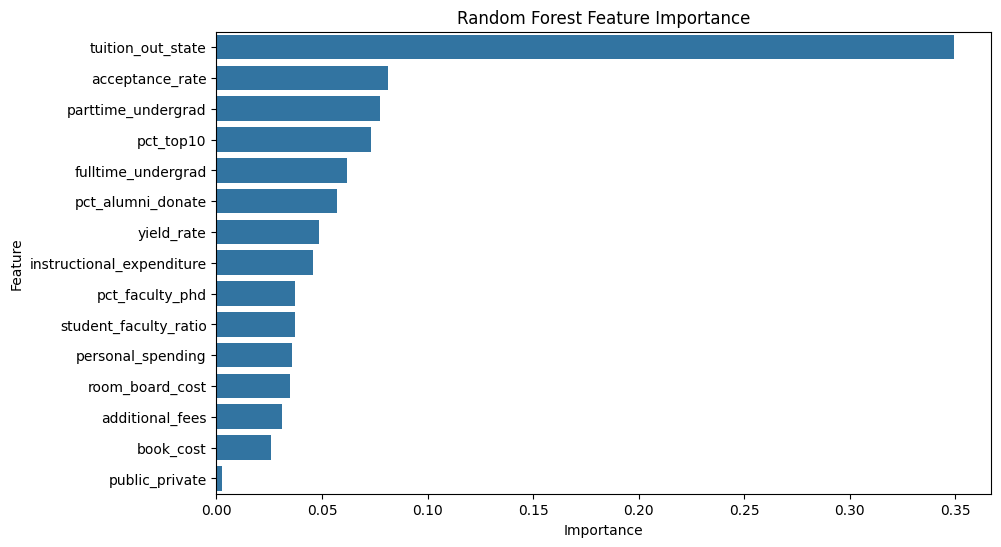

In [23]:
importances = rf.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importances = rf.feature_importances_

# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=importance_df, x="Importance", y="Feature")

plt.title("Random Forest Feature Importance")
plt.show()

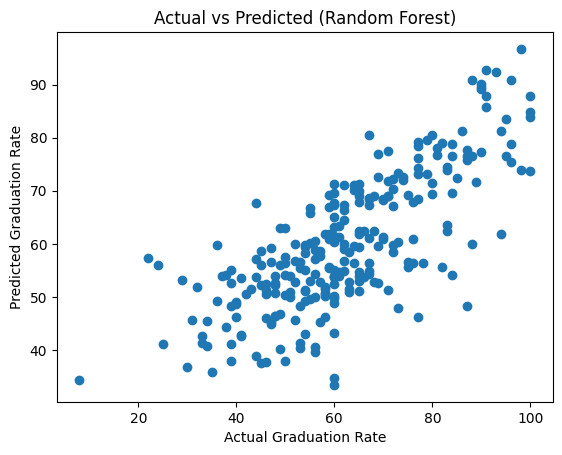

In [24]:
# Model quality
plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Graduation Rate")
plt.ylabel("Predicted Graduation Rate")

plt.title("Actual vs Predicted (Random Forest)")
plt.show()

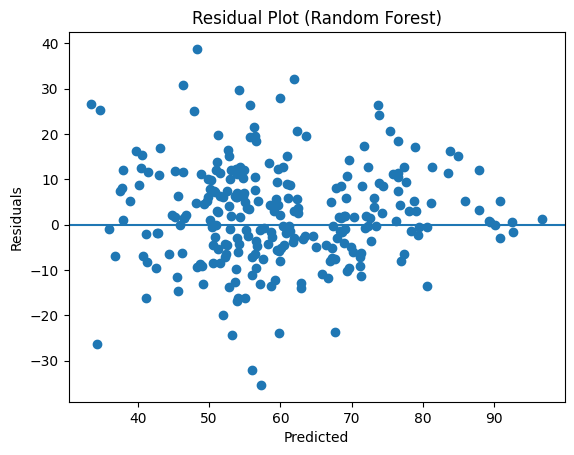

In [25]:
# Residual plot
residuals = y_test - rf_pred

plt.scatter(rf_pred, residuals)

plt.axhline(0)

plt.xlabel("Predicted")
plt.ylabel("Residuals")

plt.title("Residual Plot (Random Forest)")
plt.show()